# 01 - Cleaning and Target Definition

### Notebook idea
Celem jest wykonanie cleaningu operacyjnego danych OHLCV, zdefiniowanie targetu klasyfikacyjnego (`sell/hold/buy`) i zapisanie artefaktów do kolejnych etapów pipeline'u.

### Input
- `data/raw/ethusdt_1h.csv`

### Output
- `data/interim/eth_clean.csv`
- `data/interim/eth_labeled.csv`
- `reports/cleaning_target_metadata.json`


## Mapping to Lab6/7 Points
- **Punkt 1**: funkcja `clean_ohlcv(...)` + raport czyszczenia (braki, duplikaty, integralno?? OHLCV).
- **Punkt 2 (cz???: target EDA)**: definicja `future_return` i `target`, histogram `future_return`, rozk?ad klas.


In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from stylin import InfoDisplayStyler

In [23]:
DATA_PATH = '../../data/raw/ethusdt_1h.csv'
CLEAN_PATH = '../../data/clean/'
LABELED_PATH = '../../data/labeled/'


raw_data = pd.read_csv(DATA_PATH)
assert not raw_data.empty, "DataFrame is empty"

## Cleaning

W tym kroku przygotowujemy dane do etykietowania i dalszego modelowania:

1. Konwersja `timestamp` do formatu datetime UTC (`errors="coerce"`), usunięcie rekordów z niepoprawnym czasem.
2. Sortowanie chronologiczne po `timestamp`.
3. Usunięcie duplikatów timestamp (zostawiamy pierwszy rekord).
4. Konwersja kolumn liczbowych (`open`, `high`, `low`, `close`, `volume`, `quote_asset_volume`, `number_of_trades`, `taker_buy_*`) do typu numerycznego.
5. Usunięcie rekordów z brakami w kluczowych kolumnach numerycznych.
6. Walidacja integralności świec:
   - `high >= max(open, close)`
   - `low <= min(open, close)`
   - `volume >= 0`
   Rekordy łamiące te reguły są usuwane.
7. Ustawienie `timestamp` jako indeksu technicznego (`DatetimeIndex`) na potrzeby dalszych operacji time-series.

TIMESTAMPS: szczegółowa diagnostyka luk czasowych została wykonana w notebooku 00.
W notebooku 01 przyjmujemy politykę: brak imputacji cen, a skutki luk obsługujemy później po feature engineeringu przez `inf -> NaN -> dropna`.

In [24]:
styler = InfoDisplayStyler()

In [25]:
def clean_ohlcv(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    stats: dict[str, int] = {}
    work = df.copy()

    stats["rows_initial"] = int(len(work))

    work["timestamp"] = pd.to_datetime(work["timestamp"], utc=True, errors="coerce")
    stats["invalid_timestamp_rows"] = int(work["timestamp"].isna().sum())
    work = work.dropna(subset=["timestamp"]).copy()

    work = work.sort_values("timestamp").copy()

    duplicated_ts = int(work["timestamp"].duplicated().sum())
    stats["duplicated_timestamps"] = duplicated_ts
    work = work.drop_duplicates(subset=["timestamp"], keep="first").copy()

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_asset_volume",
        "taker_buy_quote_asset_volume",
    ]
    for col in numeric_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    stats["nan_numeric_before_drop"] = int(work[numeric_cols].isna().sum().sum())
    work = work.dropna(subset=numeric_cols).copy()

    invalid_price_nonpositive = (
        (work["open"] <= 0)
        | (work["high"] <= 0)
        | (work["low"] <= 0)
        | (work["close"] <= 0)
    )
    invalid_high = work["high"] < work[["open", "close"]].max(axis=1)
    invalid_low = work["low"] > work[["open", "close"]].min(axis=1)
    negative_volume = work["volume"] < 0

    invalid_any = invalid_price_nonpositive | invalid_high | invalid_low | negative_volume

    stats["invalid_price_nonpositive"] = int(invalid_price_nonpositive.sum())
    stats["invalid_high"] = int(invalid_high.sum())
    stats["invalid_low"] = int(invalid_low.sum())
    stats["negative_volume"] = int(negative_volume.sum())
    stats["rows_removed_integrity"] = int(invalid_any.sum())

    work = work.loc[~invalid_any].copy()

    work = work.set_index("timestamp")
    work = work.sort_index()

    stats["rows_final"] = int(len(work))
    return work, stats


clean_df, cleaning_stats = clean_ohlcv(raw_data)

styler.style_me(pd.DataFrame([cleaning_stats]), title="Cleaning stats")
styler.style_me(clean_df.reset_index().head(), title="Clean head")

,rows_initial,invalid_timestamp_rows,duplicated_timestamps,nan_numeric_before_drop,invalid_price_nonpositive,invalid_high,invalid_low,negative_volume,rows_removed_integrity,rows_final
0,46258,0,0,0,0,0,0,0,0,46258


,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2021-01-01 00:00:00+00:00,736.420000,739.000000,729.330000,734.070000,27932.698840,20479903.476036,22671,15020.616630,11015918.972215
1,2021-01-01 01:00:00+00:00,734.080000,749.000000,733.370000,748.280000,52336.187790,38899618.853014,41712,27395.902700,20362373.933503
2,2021-01-01 02:00:00+00:00,748.270000,749.000000,742.270000,744.060000,33019.501000,24606726.438367,19566,17721.266960,13207123.352084
3,2021-01-01 03:00:00+00:00,744.060000,747.230000,743.100000,744.820000,17604.808590,13119088.400414,12230,9499.749200,7079926.310875
4,2021-01-01 04:00:00+00:00,744.870000,747.090000,739.300000,742.290000,18794.154240,13980190.971469,13626,10133.742110,7539500.286872


### Thoughts after cleaning

- Po konwersji typów, sortowaniu czasu, usunięciu duplikatów i walidacji integralności świec uzyskano technicznie spójny zbiór do dalszego modelowania.  
- Dane spełniają warunki jakościowe dla OHLCV, a `timestamp` został poprawnie ustawiony jako indeks czasowy, co umożliwia bezpieczne obliczanie cech sekwencyjnych.  
- Na tym etapie nie wykonujemy imputacji cen, ponieważ mogłaby wprowadzać sztuczny sygnał rynkowy.  
- Zidentyfikowane wcześniej luki czasowe traktujemy jako incydentalne i obsługujemy ich skutki na etapie feature engineeringu przez mechanizm `inf -> NaN -> dropna`.


## Target definition (3 classes)
- `future_return = close(t+h) / close(t) - 1`
- `0 = sell` when `future_return < -threshold`
- `1 = hold` when `-threshold <= future_return <= threshold`
- `2 = buy` when `future_return > threshold`


### Wnioski po definicji targetu

Target został zdefiniowany na bazie przyszłej stopy zwrotu:

`future_return(t) = close(t+horizon) / close(t) - 1`

Dla `horizon = 6` model przewiduje kierunek ruchu ceny za 6 godzin względem ceny bieżącej.

#### Jak działa `threshold`
`threshold` wyznacza strefę „neutralną” (hold), która filtruje drobne ruchy i szum rynkowy.  
Przy `threshold = 0.0075` granice klas są następujące:

- `sell (0)`: `future_return < -0.0075`  (spadek większy niż 0.75%)
- `hold (1)`: `-0.0075 <= future_return <= 0.0075` (ruch w przedziale ±0.75%)
- `buy (2)`: `future_return > 0.0075`   (wzrost większy niż 0.75%)

Interpretacja:
- im większy `threshold`, tym więcej próbek trafi do klasy `hold` (model jest „bardziej konserwatywny”),
- im mniejszy `threshold`, tym więcej próbek trafi do `sell`/`buy` (model staje się bardziej „czuły” na małe zmiany).

Końcowe 6 rekordów (równe `horizon`) są usuwane, ponieważ nie mają dostępnej przyszłej ceny do obliczenia etykiety.


In [ ]:
HORIZON = 6
THRESHOLD = 0.0075


def make_multiclass_target(
    df: pd.DataFrame,
    horizon: int = 6,
    threshold: float = 0.0075,
    close_col: str = "close",
) -> pd.DataFrame:
    work = df.copy()
    work["future_return"] = work[close_col].shift(-horizon) / work[close_col] - 1.0

    work["target"] = 1
    work.loc[work["future_return"] < -threshold, "target"] = 0
    work.loc[work["future_return"] > threshold, "target"] = 2

    # Ostatnie rekordy nie maja etykiety (brak przyszlej ceny).
    work = work.iloc[:-horizon].copy()
    return work


labeled_df = make_multiclass_target(clean_df, horizon=HORIZON, threshold=THRESHOLD)

styler.show_line(labeled_df.shape, title="labeled_df shape")
preview_df = labeled_df.reset_index()[["timestamp", "close", "future_return", "target"]].head(10)
styler.style_me(preview_df, title="Target preview")


,timestamp,close,future_return,target
0,2021-01-01 00:00:00+00:00,734.070000,0.008037,2
1,2021-01-01 01:00:00+00:00,748.280000,-0.014567,0
2,2021-01-01 02:00:00+00:00,744.060000,-0.018802,0
3,2021-01-01 03:00:00+00:00,744.820000,-0.014957,0
4,2021-01-01 04:00:00+00:00,742.290000,-0.007383,1
5,2021-01-01 05:00:00+00:00,740.650000,-0.002430,1
6,2021-01-01 06:00:00+00:00,739.970000,-0.009163,0
7,2021-01-01 07:00:00+00:00,737.380000,0.003662,1
8,2021-01-01 08:00:00+00:00,730.070000,0.010862,2
9,2021-01-01 09:00:00+00:00,733.680000,0.002331,1


### Thoughts after target definition:

Target został zdefiniowany poprawnie jako 3-klasowa etykieta oparta o zmianę ceny `close` w horyzoncie 6 godzin:
`future_return = close(t+6h)/close(t)-1`.

Próg `threshold = 0.0075` (0.75%) tworzy strefę neutralną:
- spadek większy niż 0.75% -> `sell (0)`,
- ruch w zakresie ±0.75% -> `hold (1)`,
- wzrost większy niż 0.75% -> `buy (2)`.

Takie podejście ogranicza wpływ drobnego szumu godzinowego i wymusza klasyfikację tylko istotniejszych ruchów ceny.

Po etykietowaniu uzyskano `labeled_df shape: (46252, 11)`, co oznacza, że końcowe 6 rekordów zostało poprawnie usunięte (brak dostępnej ceny przyszłej dla `horizon=6`).

Przykładowe wiersze z `Target preview` są spójne z regułami:
wartości `future_return` powyżej `+0.0075` mają klasę `2`, poniżej `-0.0075` klasę `0`, a pomiędzy progami klasę `1`.




## Class distribution & histogram `future_return`

,target,count,ratio
0,0,11808,0.255300
1,1,21743,0.470100
2,2,12701,0.274600


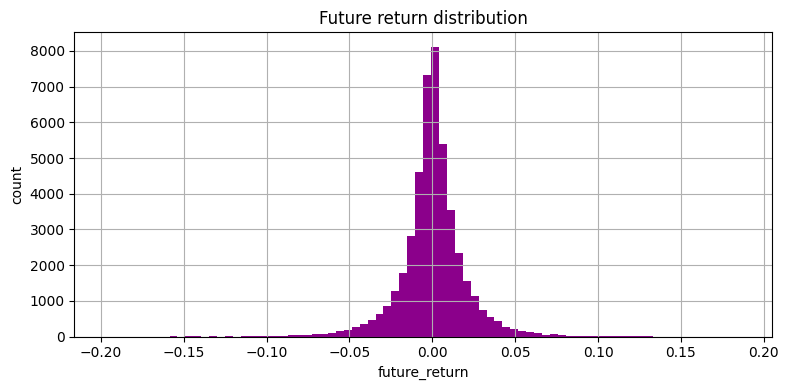

In [30]:
class_counts = labeled_df["target"].value_counts().sort_index()
class_ratio = (class_counts / len(labeled_df)).round(4)

class_report = (
    pd.DataFrame(
        {
            "target": class_counts.index.astype(int),
            "count": class_counts.values.astype(int),
            "ratio": class_ratio.values,
        }
    )
    .reset_index(drop=True)
)

styler.style_me(class_report, title="Class distribution")

plt.figure(figsize=(8, 4))
labeled_df["future_return"].hist(bins=80, color='darkmagenta')
plt.title("Future return distribution")
plt.xlabel("future_return")
plt.ylabel("count")
plt.tight_layout()
plt.show()


### After thoughts:

Rozkład klas po etykietowaniu jest umiarkowanie niezbalansowany:
- `target=0 (sell)`: **11 808** (**25.53%**)
- `target=1 (hold)`: **21 743** (**47.01%**)
- `target=2 (buy)`: **12 701** (**27.46%**)

Najliczniejsza jest klasa `hold`, co jest zgodne z intuicją dla danych godzinowych: większość ruchów w krótkim horyzoncie pozostaje w strefie neutralnej ±0.75%.

Histogram `future_return` jest silnie skupiony wokół zera, z wyraźnymi ogonami po obu stronach.  
To oznacza, że:
1. dominują małe zmiany ceny (szum krótkoterminowy),
2. większe ruchy (dodatnie i ujemne) występują rzadziej, ale są obecne.

W praktyce modelowej:
- rozkład uzasadnia użycie klasy `hold` jako strefy neutralnej,
- umiarkowana nierównowaga klas sugeruje użycie wag klas w treningu (`CrossEntropyLoss(weight=...)`), aby model nie faworyzował klasy `hold`.


### Data saving

In [28]:
os.makedirs(CLEAN_PATH, exist_ok=True)
os.makedirs(LABELED_PATH, exist_ok=True)

CLEAN_FILE = CLEAN_PATH + 'eth_clean.csv'
LABELED_FILE = LABELED_PATH + 'eth_labeled.csv'

clean_df.reset_index().to_csv(CLEAN_FILE, index=False)
labeled_df.reset_index().to_csv(LABELED_FILE, index=False)

print("Saved:", CLEAN_FILE)
print("Saved:", LABELED_FILE)

Saved: ../../data/clean/eth_clean.csv
Saved: ../../data/labeled/eth_labeled.csv


### Thoughts at the end of this notebook:

W notebooku 01 zrealizowano etap przygotowania danych do problemu klasyfikacji 3-klasowej (`sell/hold/buy`).  
Cleaning zapewnił spójność techniczną zbioru (poprawne typy danych, porządek chronologiczny, brak niespójnych rekordów OHLCV), a dane zostały przygotowane w formie gotowej do etykietowania i dalszego pipeline’u.

Definicja targetu oparta o `future_return` w horyzoncie `6h` i próg `threshold=0.0075` (±0.75%) jest metodologicznie spójna:  
- duże spadki trafiają do `sell`,  
- małe ruchy do `hold`,  
- duże wzrosty do `buy`.  

Po etykietowaniu uzyskano zbiór `labeled_df` o rozmiarze **46 252** obserwacji, a przykładowe rekordy potwierdzają poprawne przypisanie klas względem reguł progowych.

Rozkład klas jest umiarkowanie niezbalansowany (`hold` ~47%, `sell` ~25.5%, `buy` ~27.5%), a histogram `future_return` pokazuje koncentrację wokół zera i rzadsze wartości skrajne.  
To potwierdza sens zastosowanej strefy neutralnej oraz uzasadnia użycie wag klas w kolejnych etapach treningu.